# 02 — Caso A: energia condivisa, sorgente monoenergetica

**Assunzioni:** sorgente unica e monoenergetica, direzione del neutrone nota (lungo $z$).
Il parametro condiviso è $E_n$. Per ogni evento, l'angolo vero $\theta_p$ è una nuisance e viene
marginalizzato.

Per evento, la verosimiglianza è
$$L_k(E_n) = \int d\theta\, \pi(\theta)\, N(\hat E_p; E_n\cos^2\theta, \sigma_{E_p})\,
N(\hat\theta_p; \theta, \sigma_\theta).$$
Gli eventi si combinano sommando le log-verosimiglianze, con il prior contato una sola volta:
$\log p(E_n\mid D_{1:N}) = \log\pi(E_n) + \sum_k \log L_k(E_n)$, valida se gli eventi sono
condizionatamente indipendenti dato $E_n$.

**Etichette dei risultati.** (a) fatto consolidato · (b) stima toy con assunzioni esplicite ·
(c) verificato con Monte Carlo · (d) ipotesi da testare.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from scipy.stats import kstest, norm

from riptide_toy.constants import SEED, SIGMA_EP, SIGMA_THETA, EN_MIN, EN_MAX

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(SEED)
from riptide_toy import forward_model, grids, kinematics, posterior_A, priors, validate
from riptide_toy.combine import combine_loglik, expected_sigma_n

en_grid = grids.energy_grid()
prior_En = priors.energy_prior(en_grid)


def mean_sigma(logpost, grid):
    w = np.exp(logpost - logpost.max())
    m = np.sum(w * grid) / np.sum(w)
    return m, np.sqrt(np.sum(w * (grid - m) ** 2) / np.sum(w))

## Caso di riferimento R1 — un singolo evento

Un evento con $\hat E_p = 1.40$ MeV e $\hat\theta_p = 0.50$ rad, risoluzioni $\sigma_{E_p} = 0.10$ MeV e
$\sigma_\theta = 0.08$ rad, prior piatto (proprio) su $E_n$.

Valore atteso per propagazione lineare **(b)**. La stima puntuale è
$\hat E_n = \hat E_p/\cos^2\hat\theta_p = 1.40/0.770 = 1.82$ MeV. L'incertezza somma in quadratura i due
contributi:
$$\sigma_{E_n}^2 = \Big(\frac{\sigma_{E_p}}{\cos^2\hat\theta_p}\Big)^2 + \big(2\hat E_n\tan\hat\theta_p\,\sigma_\theta\big)^2
= 0.130^2 + 0.159^2 \;\Rightarrow\; \sigma_{E_n} \approx 0.21\ \text{MeV}.$$
Il posterior esatto sulla griglia deve dare $E_n = 1.82 \pm 0.21$ MeV. È asimmetrico (coda verso $E_n$
alti, dove $\cos^2\theta$ è piccolo), quindi media e MAP differiscono di qualche centesimo.

MAP = 1.801 MeV, media = 1.856, sigma = 0.219 MeV   (atteso: 1.82 +- 0.21)


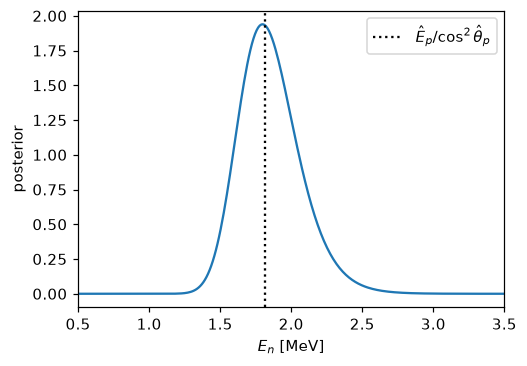

In [2]:
D = (np.array([1.40]), np.array([0.50]))
logpost = posterior_A.single_event_posterior(D, en_grid, prior_En)[0]
m, s = mean_sigma(logpost, en_grid)
print(f"MAP = {en_grid[np.argmax(logpost)]:.3f} MeV, media = {m:.3f}, sigma = {s:.3f} MeV   (atteso: 1.82 +- 0.21)")

w = np.exp(logpost - logpost.max())
plt.figure(figsize=(5, 3.5))
plt.plot(en_grid, w / trapezoid(w, en_grid))
plt.axvline(1.40 / np.cos(0.50) ** 2, color="k", ls=":", label=r"$\hat E_p/\cos^2\hat\theta_p$")
plt.xlim(0.5, 3.5); plt.xlabel("$E_n$ [MeV]"); plt.ylabel("posterior"); plt.legend()
plt.show()

Il posterior è asimmetrico. $E_n$ dipende da $\theta$ attraverso $1/\cos^2\theta$, che è
convessa: l'incertezza angolare allarga soprattutto la coda verso le alte energie.

## Caso di riferimento R2 — combinare due eventi

Due eventi con verosimiglianze circa gaussiane, $N(2.70, 0.45)$ e $N(2.35, 0.20)$ MeV. La combinazione
(somma delle log-verosimiglianze) deve dare la media pesata con $1/\sigma^2$:
$\hat E_n = (2.70/0.45^2 + 2.35/0.20^2)/(1/0.45^2 + 1/0.20^2) = 2.40$ MeV, con
$\sigma = (1/0.45^2 + 1/0.20^2)^{-1/2} = 0.18$ MeV **(a)**.

combinato: 2.408 +- 0.183 MeV   (atteso: 2.40 +- 0.18)
media pesata analitica: 2.408 +- 0.183


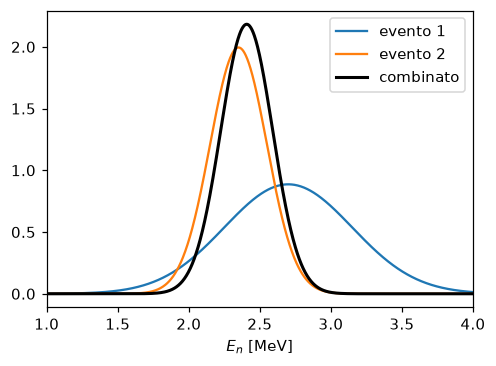

In [3]:
grid = np.linspace(0.5, 6.0, 2000)
ll = np.stack([-0.5 * ((grid - 2.70) / 0.45) ** 2, -0.5 * ((grid - 2.35) / 0.20) ** 2])
combined = combine_loglik(ll, np.zeros_like(grid))
m, s = mean_sigma(combined, grid)
print(f"combinato: {m:.3f} +- {s:.3f} MeV   (atteso: 2.40 +- 0.18)")
wm = (2.70 / 0.45**2 + 2.35 / 0.20**2) / (1 / 0.45**2 + 1 / 0.20**2)
print(f"media pesata analitica: {wm:.3f} +- {(1 / 0.45**2 + 1 / 0.20**2) ** -0.5:.3f}")

plt.figure(figsize=(5, 3.5))
for row, lab in zip(ll, ("evento 1", "evento 2")):
    plt.plot(grid, np.exp(row) / trapezoid(np.exp(row), grid), label=lab)
w = np.exp(combined - combined.max())
plt.plot(grid, w / trapezoid(w, grid), "k", lw=2, label="combinato")
plt.xlim(1, 4); plt.xlabel("$E_n$ [MeV]"); plt.legend(); plt.show()

## Contrazione del posterior con N

Si simulano eventi con $E_n = 2.5$ MeV e $\theta_p \sim U(0,\pi/2)$, coerente con il prior uniforme su
$\theta$ della verosimiglianza del Caso A. Poi si combinano i primi $N$ eventi.
Se gli eventi sono indipendenti, la larghezza scende come $\sigma_1/\sqrt N$ **(c)**.

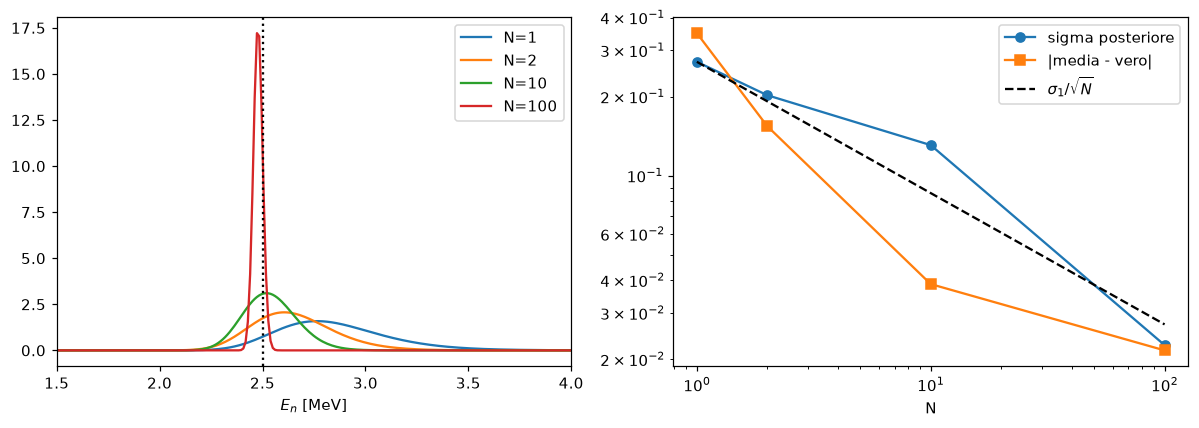

N=   1  sigma=0.2713  sigma_1/sqrt(N)=0.2713  |offset|=0.3487
N=   2  sigma=0.2024  sigma_1/sqrt(N)=0.1918  |offset|=0.1542
N=  10  sigma=0.1307  sigma_1/sqrt(N)=0.0858  |offset|=0.0386
N= 100  sigma=0.0226  sigma_1/sqrt(N)=0.0271  |offset|=0.0216


In [4]:
EN_TRUE = 2.5
n_max = 5000
theta_true = rng.uniform(0, np.pi / 2, n_max)
Ep_true = kinematics.proton_energy(EN_TRUE, theta_true)
D = forward_model.measure(Ep_true, theta_true, SIGMA_EP, SIGMA_THETA, rng)

th_grid = grids.theta_p_grid()
log_prior_theta = np.full(th_grid.shape, -np.log(th_grid.size))
log_prior_En = np.log(prior_En)
ll = forward_model.loglik(D, en_grid, th_grid, SIGMA_EP, SIGMA_THETA, log_prior_theta, chunk_size=100)

N_VALUES = [1, 2, 10, 100]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sig, off = [], []
for n in N_VALUES:
    c = combine_loglik(ll[:n], log_prior_En)
    m, s = mean_sigma(c, en_grid)
    sig.append(s); off.append(abs(m - EN_TRUE))
    w = np.exp(c - c.max())
    axes[0].plot(en_grid, w / trapezoid(w, en_grid), label=f"N={n}")
axes[0].axvline(EN_TRUE, color="k", ls=":")
axes[0].set_xlim(1.5, 4); axes[0].set_xlabel("$E_n$ [MeV]"); axes[0].legend()
axes[1].loglog(N_VALUES, sig, "o-", label="sigma posteriore")
axes[1].loglog(N_VALUES, off, "s-", label="|media - vero|")
axes[1].loglog(N_VALUES, expected_sigma_n(sig[0], np.array(N_VALUES)), "k--", label=r"$\sigma_1/\sqrt{N}$")
axes[1].set_xlabel("N"); axes[1].legend()
plt.tight_layout(); plt.show()
for n, s, o in zip(N_VALUES, sig, off):
    print(f"N={n:4d}  sigma={s:.4f}  sigma_1/sqrt(N)={sig[0] / np.sqrt(n):.4f}  |offset|={o:.4f}")

### Un sistematico comune non si media via

Si ripete l'esercizio con un errore di scala del 2% su $E_p$, comune a tutti gli eventi. La
larghezza statistica continua a scendere come $1/\sqrt N$, ma l'offset si ferma su un plateau:
un errore condiviso da tutti gli eventi non si riduce combinandoli. Nella checklist di validazione
un plateau nella contrazione è il segnale di un sistematico condiviso **(c)**.

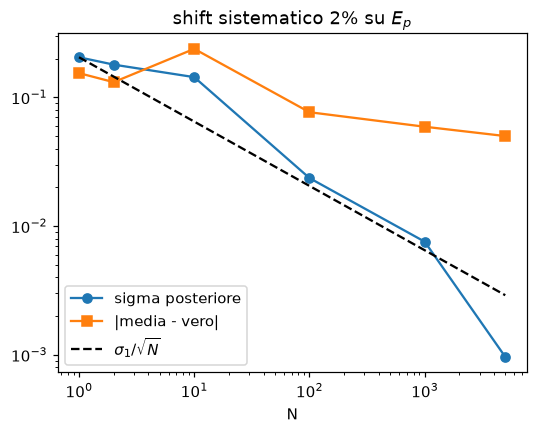

N=    1  sigma=0.2051  |offset|=0.1545
N=    2  sigma=0.1798  |offset|=0.1314
N=   10  sigma=0.1437  |offset|=0.2385
N=  100  sigma=0.0236  |offset|=0.0767
N= 1000  sigma=0.0076  |offset|=0.0592
N= 5000  sigma=0.0010  |offset|=0.0501


In [5]:
D_shift = forward_model.measure(1.02 * Ep_true, theta_true, SIGMA_EP, SIGMA_THETA, rng)
ll_shift = forward_model.loglik(D_shift, en_grid, th_grid, SIGMA_EP, SIGMA_THETA, log_prior_theta, chunk_size=100)
N_SHIFT = [1, 2, 10, 100, 1000, 5000]
res = np.array([mean_sigma(combine_loglik(ll_shift[:n], log_prior_En), en_grid) for n in N_SHIFT])

plt.figure(figsize=(5.5, 4))
plt.loglog(N_SHIFT, res[:, 1], "o-", label="sigma posteriore")
plt.loglog(N_SHIFT, np.abs(res[:, 0] - EN_TRUE), "s-", label="|media - vero|")
plt.loglog(N_SHIFT, res[0, 1] / np.sqrt(N_SHIFT), "k--", label=r"$\sigma_1/\sqrt{N}$")
plt.xlabel("N"); plt.legend(); plt.title("shift sistematico 2% su $E_p$"); plt.show()
for n, (m, s) in zip(N_SHIFT, res):
    print(f"N={n:5d}  sigma={s:.4f}  |offset|={abs(m - EN_TRUE):.4f}")

L'offset si ferma attorno a 0.05 MeV, cioè il 2% di $E_n$, mentre la larghezza statistica è ormai
di un ordine di grandezza più piccola: da lì in avanti aggiungere eventi non migliora la stima.
Nella contrazione senza sistematico, invece, a N molto piccolo il rapporto con $\sigma_1/\sqrt N$ non è
esatto: il posterior di pochi eventi non è gaussiano e la scala $1/\sqrt N$ vale solo in regime
asintotico.

## Caso di riferimento R3 — la checklist smaschera una ricostruzione difettosa

Si costruisce una ricostruzione volutamente sbagliata:
$\hat E = 1.03\,E + 0.05 + \varepsilon$, con $\varepsilon\sim N(0, 0.08E)$ e un'incertezza dichiarata
più stretta del 30% ($\hat\sigma = 0.7\cdot 0.08E$). Su 20 000 eventi con $E\sim U(1,5)$ ci si aspetta:

- bias $0.03E + 0.05$, cioè da ≈ 0.08 MeV nel primo bin a ≈ 0.20 MeV nell'ultimo;
- pull con larghezza $1/0.7 \approx 1.4$ e media ≈ 0.9 (il bias diviso per $\hat\sigma$);
- copertura dell'intervallo al 68% nominale che scende a ≈ 45%, per l'effetto combinato di bias
  e intervalli troppo stretti.

bias primo/ultimo bin: 0.080 / 0.179 MeV   (atteso 0.08 / 0.20)
pull: media 0.90, larghezza 1.44   (atteso 0.9 / 1.4)
coverage 68% nominale: 0.434   (atteso ~0.45)


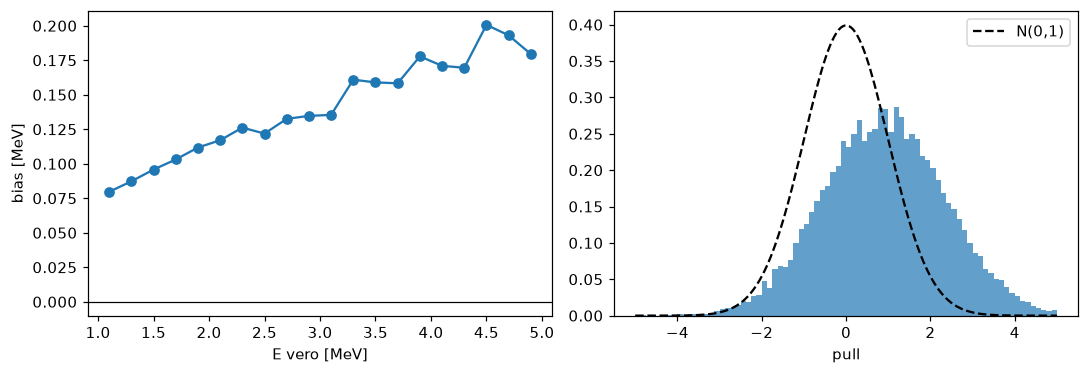

In [6]:
def faulty(truth, rng):
    true_sigma = 0.08 * truth
    est = 1.03 * truth + 0.05 + rng.normal(0.0, true_sigma)
    sigma_hat = 0.7 * true_sigma
    z = norm.ppf(0.5 + np.array([0.68]) / 2)
    hw = z[None, :] * sigma_hat[:, None]
    return est, sigma_hat, np.stack([est[:, None] - hw, est[:, None] + hw], axis=-1)

truth = rng.uniform(1.0, 5.0, 20_000)
r = validate.run_checklist(faulty, truth, levels=np.array([0.68]), rng=rng)
print(f"bias primo/ultimo bin: {r['bias'][0]:.3f} / {r['bias'][-1]:.3f} MeV   (atteso 0.08 / 0.20)")
print(f"pull: media {r['pull_mean']:.2f}, larghezza {r['pull_width']:.2f}   (atteso 0.9 / 1.4)")
print(f"coverage 68% nominale: {r['coverage'][0]:.3f}   (atteso ~0.45)")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(r["bias_centers"], r["bias"], "o-"); axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_xlabel("E vero [MeV]"); axes[0].set_ylabel("bias [MeV]")
est, sh, _ = faulty(truth, rng)
x = np.linspace(-5, 5, 200)
axes[1].hist(validate.pull_histogram(truth, est, sh), bins=80, range=(-5, 5), density=True, alpha=0.7)
axes[1].plot(x, norm.pdf(x), "k--", label="N(0,1)"); axes[1].set_xlabel("pull"); axes[1].legend()
plt.tight_layout(); plt.show()

I numeri riproducono i valori attesi. Il bias dell'ultimo bin può uscire un po' sotto 0.20 MeV:
è una fluttuazione statistica del bin più popolato a energie alte, dove lo scatter vale $0.08E$.

## Checklist sulla ricostruzione reale del Caso A

La stessa checklist si applica al posterior del Caso A. Ogni evento ha un proprio $E_n$ vero,
estratto da $U(1,5)$. La stima è la media del posterior di singolo evento, l'incertezza la sua
deviazione standard, e gli intervalli credibili sono letti direttamente dalla griglia **(c)**.

pull: media +0.122, larghezza 0.943
coverage: {np.float64(0.68): np.float64(0.725), np.float64(0.9): np.float64(0.923), np.float64(0.95): np.float64(0.963)}


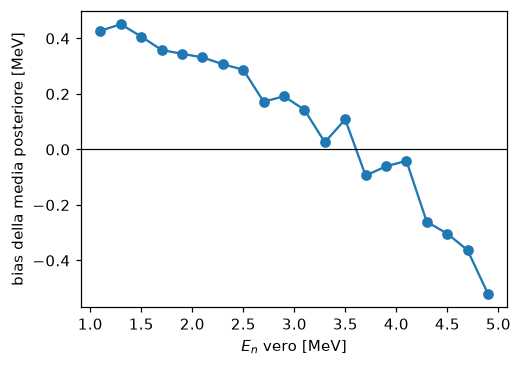

In [7]:
LEVELS = np.array([0.68, 0.90, 0.95])

def reco_A(truth, rng):
    th = rng.uniform(0, np.pi / 2, truth.size)
    D = forward_model.measure(kinematics.proton_energy(truth, th), th, SIGMA_EP, SIGMA_THETA, rng)
    # a blocchi di 50 eventi per contenere la memoria
    lp = np.concatenate([posterior_A.single_event_posterior((D[0][i:i + 50], D[1][i:i + 50]), en_grid, prior_En)
                         for i in range(0, truth.size, 50)])
    est, sig = validate.posterior_mean_std(lp, en_grid)
    return est, sig, validate.credible_interval(lp, en_grid, LEVELS)

truth = rng.uniform(1.0, 5.0, 5000)
rA = validate.run_checklist(reco_A, truth, levels=LEVELS, rng=rng)
print(f"pull: media {rA['pull_mean']:+.3f}, larghezza {rA['pull_width']:.3f}")
print("coverage:", dict(zip(LEVELS, np.round(rA["coverage"], 3))))
plt.figure(figsize=(5, 3.5))
plt.plot(rA["bias_centers"], rA["bias"], "o-"); plt.axhline(0, color="k", lw=0.8)
plt.xlabel("$E_n$ vero [MeV]"); plt.ylabel("bias della media posteriore [MeV]"); plt.show()

Lettura: la copertura è la verifica più diretta di calibrazione. Qui è leggermente sopra il
nominale (circa 72% al 68%) e la larghezza del pull è un po' sotto 1: il posterior del Caso A è
lievemente conservativo, il che è preferibile al contrario. Un eventuale bias ai bordi del
dominio $[0.5, 6]$ MeV è atteso, perché il prior proprio tronca il posterior e la media viene
spinta verso l'interno. È un effetto del prior, non un difetto della verosimiglianza.